In [7]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import numpy as np

    Sound is a continuously wiggling wave - air pressure going up and down thousands of times per second.

`Sample Rate = 44100 Hz (CD-quality standard) = 44.1 kHz` -> technically speaking, this is *how many measurements of air pressure (voltage from a pickup here) were taken per second, when the audio was recorded*. It is a property of ***how finely we sliced time to capture it***. 

-> *But why is 44100 the standard? -> Because we need at least twice as many snapshots per second as the highest frequency we want to capture.*  
    
    Max human hearing ~= 20000 Hz, now doubling that, we get 40000 and adding a little safety margin, we finally have 44100 Hz. That's literally the whole reason for this specific number.

In [8]:
data, sr = sf.read("bass_guitar.wav")

print("Sample rate:", sr)
print("Data shape:", data.shape)
print("Dtype:", data.dtype)
print("Duration (seconds):", data.shape[0] / sr)
print("Min/Max:", data.min(), data.max())

Sample rate: 44100
Data shape: (361472, 2)
Dtype: float64
Duration (seconds): 8.196643990929704
Min/Max: -0.76806640625 0.94775390625


`Dtype: float64 (64-bit floating point number)` -> 8 bytes per sample.   
`wav files` are almost always stored as `int16` - CD standard. The library `soundfile` silently converted the data to float64, when loaded, but the raw wav file on the hard drive is probably still int16 underneath.

##### **If the data is still int16 in the memory, and upcasting like this doesn't add any information, so what's the point?**
Yes, the audio was captured and quantized at 16-bit resolution. Converting to float64 doesn't recover any detail that wasn't there already - bit-for-bit, informationally, nothing changed.

But it makes sense the moment we do some math on it.  
- The maximum int16 can hold is 32,767. We go one step up, and it doesn't give 32,768, but -32,768 instead. It went past the edge and wrapped around, landing somewhere deep in the negatives. This doesn't raise an error but is a completely wrong number that the speaker would then play as a violent crack. Float doesn't have this "wraparound" problem because its maximum is an astronomically large number. We will never accidentally overflow a float doing audio math. It just holds whatever number we give it.
- Mixing two tracks, applying a filter or FFT, normalization or scaling and a few chained operations can all lead to thw wraparound problem with the fixed-width integers.

##### **Why are the image arrays unsigned, but this is signed?**
This comes down to what the numbers actually represent. A sound wave, if you visualize it, goes above and below zero - it's the air pressure fluctuating around a resting equilibrium. Above equilibrium = positive. Below equilibrium = negative. Zero = silence, the resting state.  
If we forced the audio into unsigned (0-255 like uint8), 128 would represent "silent", 255 would be the loud positive peak and 0 the loud negative peak. 
Mathematically, it's deeply unnatural. Here, signed integers are simply clean, more intuitive and physically meaningful.

`Min/Max: -0.76806640625, 0.94775390625`: this is the actual range of values in the array. These numbers are just the tallest peak upward and the deepest dip downward the bass guitar reached in this entire 8-second clip.
By convention, the wave lives between -1.0 and +1.0.  

    0.0 = complete silence (flat line)
    +1.0 = loudest possible positive peak
    -1.0 = loudest possible negative peak

The above numbers show that the bass guitar hit -0.768 at its deepest and +0.947 at its highest. It never hit -1.0/+1.0 - which is good. Hitting exactly 1.0 means `clipping` (it is that harsh crackling distortion we hear when something is recorded too loud).

*The fact that the positive peak (0.947) is higher than the negative peak (0.768) is completely normal - real instrument waves are rarely perfectly symmetrical.*

In [9]:
print(data[:10])  # Print the first 10 samples of the audio data

[[ 0.00384521 -0.00033569]
 [ 0.00509644 -0.00076294]
 [ 0.00979614  0.00411987]
 [ 0.00726318  0.00119019]
 [ 0.00753784  0.00222778]
 [ 0.00674438  0.00143433]
 [ 0.00714111  0.00137329]
 [ 0.00643921  0.00042725]
 [ 0.00765991  0.00131226]
 [ 0.0078125   0.00140381]]


`Data Shape = (361472, 2)` -> The data shape is just `time, channels`. 
*Channels here are speaker channels (playback routing) -> they say nothing about how many instruments or mics went in.*   
The array has 2 columns, implying this audio file is `stereo`. `361472` is the total number of snapshots in time, so when we divide this number with our sampling rate, we get the duration (~8.2 seconds of audio). The two separate channels of samples, are most likely left and right ear. 

As we can see from above, the whole shape is a rectangular grid. Each row represents a snap (a moment in time), and each column is one speaker. The headphones take column 0 and send it to the left ear and take column 1 and send it to the right ear.

---
*Note: there's a whole ladder of channels: Mono → Stereo → Surround*   

    Mono is one speaker. Stereo is two (left/right). But surround sound keeps adding more speakers placed around us in physical space (Every movie theater uses it).
    Stereo fakes depth by balancing volume between two speakers. Surround sound puts an actual speaker where the sound is supposed to come from.

*If it were 5.1 surround sound (meaning 5 full-range speakers and one subwoofer), it'd be (361,472, 6) - six channels: front-left, front-right, center, subwoofer, rear-left, rear-right.*

*The ladder goes even further than 5.1. There's 7.1, then atmos/9.1.4 (for true 3D sound).*

In [10]:
print(np.allclose(data[:, 0], data[:, 1]))

diff = np.abs(data[:, 0] - data[:, 1])
print("Max difference between channels: ", diff.max())
print("Min difference between channels: ", diff.min())

False
Max difference between channels:  0.184478759765625
Min difference between channels:  0.0


`np.allclose(data[:, 0], data[:, 1])` compares the left and right channels element-by-element and return a `True` or `False` value. 
It simply asks *if the two channels are close enough to be considered identical*?

- If it prints True: the file is effectively mono pretending to be stereo. The same signal was just duplicated into both channels.
- If it prints False: there's genuine stereo information. The left and right ears are hearing something different.

We check the same thing by computing the sample-by-sample difference between channels and then take the absolute value, so that negatives don't cancel out the positives. 

##### **Why do we care if the given audio is true mono/stereo? Why not just move on with *stereo* if we see 2 channels?**

Yes, for playback it makes no difference, but if it matters or not actually depends on what we intend to do next with the array.

**If doing audio ML:**   

    most models expect mono - they take 1D input (we take the mean for a stereo file to collapse it to mono). So, knowing if the file was already a fake-stereo, we can just take either channels and move on. But, if it's a genuine stereo, it carries spatial information. The difference between channels is data, and averaging it away destroys it.
**If doing processing or analysis:**  
 
    If building a dataset from many audio files, some might be true stereo and some fake-stereo. Treating them inconsistently means the arrays have different information densities - one file's channel difference is signal, another's is just zeros. That inconsistency, silently corrupts the whole training set.

In [11]:
# Let's check the memory layout

print("Strides:", data.strides)
print("C-contiguous:", data.flags.c_contiguous)
print("---\n")

print("Left channel strides:", data[:, 0].strides)
print("Left channel (C-contiguous):", data[:, 0].flags.c_contiguous)

print("Right channel strides:", data[:, 1].strides)
print("Right channel (C-contiguous):", data[:, 1].flags.c_contiguous)

Strides: (16, 8)
C-contiguous: True
---

Left channel strides: (16,)
Left channel (C-contiguous): False
Right channel strides: (16,)
Right channel (C-contiguous): False


`Strides: (16, 8)` mean that to jump from one row to the next, we have to skip 16 bytes (2*8 bytes); or to jump from left to right there is a jump of 8 bytes.
And as we know, the datatype of each value stored is float64 (8 bytes), it makes sense.

C-contiguous means rows are stored contiguously - as we walk forward in memory, we move through the row first, then jump to the next row. The full array is genuinely C-contiguous - every element is right next to the next one with no gaps.

So, in memory the data is laid out like: 
`[L0, R0, L1, R1, L2, R2, L3, R3, ...]`
Left and right samples are interleaved - alternating, sitting right next to each other. This is called `interleaved audio`, and it's the standard layout for stereo WAV files on disk. When accessing the left and right channels individually, the data again becomes non-contiguous.

---

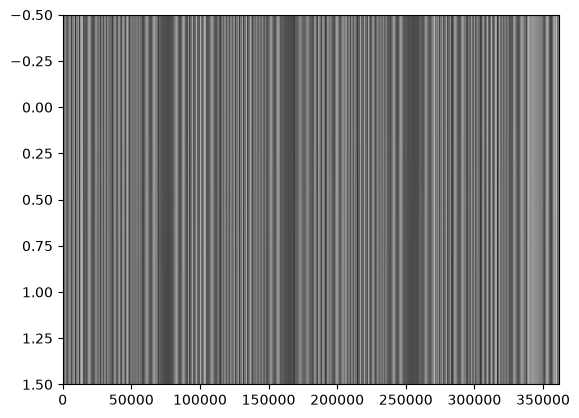

In [12]:
plt.imshow(data.T, aspect="auto", cmap="gray")

    An audio array is a record of air pressure over time. That representation, while complete, tells us almost nothing useful by looking at it. All we see is some lines. The information is all there, but it's encoded in a way that's opaque to us.

The core idea here is that - ***no matter how complicated or messy it looks, every repeating wave can be perfectly described as a sum of simple sine waves of different frequencies, amplitudes and phases.***

A bass guitar string plucked once produces a wave that looks chaotic, but it is secretly just:

- a sine wave at 41 Hz (the fundamental note, say low E)
- a quieter sine wave at 82 Hz (second harmonic)
- a quieter one at 123 Hz (third harmonic)
- and so on, getting quieter as we go up

The FFT's job is to go backwards i.e to take the messy sum, and figure out what sine waves were added together to make it.

---
data.T has shape (2, 361472) - 2 rows, 361472 columns. When imshow draws this, the y-axis is not amplitude at all - it's the row index of the image, i.e. "which channel." Matplotlib's default extent for a 2-row image pads half a pixel on each side, giving exactly -0.5 to 1.5. That's just pixel bookkeeping for "2 rows," coincidentally in the same numeric neighborhood as your audio range, but semantically unrelated to it.

The genuinely correct version of your underlying point - that imshow is treating your waveform as "arbitrary pixel intensities, not as a waveform" - is real, but it shows up in the color/brightness mapping, not the y-axis. By default, imshow normalizes color intensity using vmin=data.min(), vmax=data.max() of whatever you feed it - so your -0.768-to-0.947 range does get used, just to decide what counts as "blackest" and "whitest" pixel, not to label the y-axis. So the observation survives, but the evidence you pointed to for it doesn't - worth swapping in the color-normalization explanation instead. It's a good instinct (noticing the mismatch) that just grabbed the wrong axis as proof.

---

### Framing the Signal

In the above section, we closely observed and understood what a raw audio array is. I've decided that frequency-domain stuff is out of the scope of this very notebook. But there's a step before that, which is purely about memory and array mechanics - **framing** -> cutting the signal into small, fixed size, overlapping chunks.  

If I were to cut the bass clip into small overlapping chunks (frames), there are two numbers that control everything here: `frame size` (how many samples per chunk) and `hop size` (how many samples we move forward before cutting the next chunk). 

Let's think. `If a bass guitar's lowest note is ~41 Hz (frequency of low E), then it completes one full wave cycle in T = 1/41 = ~24 ms.`   
If the frame is shorter than one full wave cycle, then the contents of the frame become useless. It is not meaningful enough to say anything about the note we have.

Given `sr=44100 samples/second`, the number of samples that correspond to 24 ms = 44100*24 = ~1058 samples.

=> one full cycle of our lowest bass note takes roughly 1058 samples - anything much shorter than that literally can't contain one complete wobble of the lowest note.

In practice, frame sizes are almost always picked as powers of 2 -> this is because of the future algorithm that will eventually consume these frames. For now let's just be satisfied by knowing that the algorithm strongly prefers power-of-2 input sizes for efficiency reasons.

Given the floor value of ~1058 samples, we pick 2^11 as our frame size, because 1024 falls short of the 1058-sample cycle, and would clip off a few data points on the lowest note. 2^11 comfortably covers one full low-E cycle. This maps to about 46 ms of audio per frame at 44.1 kHz.

--- 
Hop Size: Talking about extremes first, a hop of 2048 implies there would be no overlap between 2 frames and they would sit right next to each other; and a hope of 1 would mean that nearly every frame overlaps entirely with the one before it. As absurd as these two cases sound, neither of them are actually used in practice. 

It doesn't make sense to have non-overlapping, consecutive frames as if the note is sharp pluck and sits right at the boundary between 2 frames, our ability to see that `transient` cleanly in either frame is now significantly reduced. It's not only about transients landing on a hard boundary. When we actually cut a frame out of a continuous signal, we don't take it as a harsh rectangular slice, instead we taper its edges toward zero (this is what a "window function" does). That tapering means the edges of every frame are deliberately weakened/suppressed compared to the middle. If frames don't overlap, we'd be systematically losing information right at every frame boundary -> twice, from both sides.

Hence we need overlapping to have clearer picture of the different frequencies we might observe and to also avoid such cases, as we discussed just now.

Given all this information, it all makes sense if there is an overlap somewhere midway. The common practice is `50% to 75% overlap` (i.e. hop size = frame_size / 2, or even frame_size / 4). Heavy overlap (50–75%) compensates the edge value tapering: what gets suppressed at the edge of one frame gets picked up strongly in the middle of the next one.

In [19]:
left = data[:, 0]
N = left.shape[0] # total samples
frame_length = 2048
hop_length = 512

print(f"Total samples: {N}\n", "Frame size: 2048\n", "hop size: 512")

Total samples: 361472
 Frame size: 2048
 hop size: 512


In [27]:
def naive_framing(signal, frame_length, hop_length):
    n_frames = 1 + (signal.shape[0] - frame_length) // hop_length
    frames = np.empty((n_frames, frame_length), dtype=signal.dtype)
    for i in range(n_frames):
        start = i *hop_length
        frames[i] = signal[start:start + frame_length]
    return frames

frames_loop = naive_framing(left, frame_length=2048, hop_length=512)
print("Loop-based frames shape:", frames_loop.shape)
print("(n_frames, frame_length) -> each row is one 2048-sample window")

print("Strided frames shape: ", frames_loop.shape)
print("Dtype: ", frames_loop.dtype)
print("Strides: ", frames_loop.strides)
print("C-contiguous: ", frames_loop.flags["C_CONTIGUOUS"])
print("Copy or a View: ", 
      "COPY" if frames_loop.flags['OWNDATA'] == True
      else "VIEW")

Loop-based frames shape: (703, 2048)
(n_frames, frame_length) -> each row is one 2048-sample window
Strided frames shape:  (703, 2048)
Dtype:  float64
Strides:  (16384, 8)
C-contiguous:  True
Copy or a View:  COPY


In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

all_windows = sliding_window_view(left, frame_length)
frames_strided = all_windows[::hop_length]

print("All windows shape: ", all_windows.shape)
print("Strided frames shape: ", frames_strided.shape)
print("Dtype: ", frames_strided.dtype)
print("Strides: ", frames_strided.strides)
print("C-contiguous: ", frames_strided.flags["C_CONTIGUOUS"])
print("Copy or a View: ", 
      "COPY" if frames_strided.flags['OWNDATA'] == True
      else "VIEW")

print("Same values as the loop version?: ", np.array_equal(frames_loop, frames_strided))

Strided frames shape:  (703, 2048)
Dtype:  float64
Strides:  (8192, 16)
C-contiguous:  False
Copy or a View:  VIEW
Same values as the loop version?:  True


Both implementations agree exactly - 703 frames, either way. 

But, a few other things are different.
- When used loops, `Strides:  (16384, 8)`, but next time `Strides:  (8192, 16)`: np.empty((703, 2048)) allocates a brand-new, freshly-owned block of memory (owndata: True), laid out C-contiguous, exactly like any normal 2D array. Its strides are just the standard formula for a fresh contiguous array: to move one row down, skip 2048 samples × 8 bytes = 16384 bytes; to move one column over, skip 8 bytes (one float64). There's nothing clever here - you copied 2048 fresh values into each row, so of course it looks like an ordinary array. This is a genuine copy - every frame's data is duplicated in memory, and since frames overlap 75%, most of your bytes now exist 4 times over.

Strided version: strides = (4096, 8), owndata: False
This one is not a new array — it's a view into the same original left buffer, just relabeled with different strides so NumPy pretends there are extra dimensions. Nothing was copied. Here's the derivation:

sliding_window_view(left, 2048) first creates every possible overlapping window (hop=1 conceptually) — that's why its shape is (359425, 2048) and its strides are (8, 8): move one window forward = skip 8 bytes (1 sample) in the same underlying buffer; move one column = skip 8 bytes too. Both dimensions are walking over the exact same bytes, just starting one sample apart — that's the whole trick of a sliding window view: massive apparent size, zero actual new memory.
Then all_windows[::hop_length] just says "keep every 512th window." Since each step between windows was originally 8 bytes, skipping 512 of those steps makes the new row-stride 512 × 8 = 4096 bytes. The column stride stays 8 because you still haven't moved to new memory within a row — you're just reading the same original array at a wider spacing between starting points.